In [1]:
import numpy as np

# Propostion Validations

In [2]:
C = {}
C['s0'] = 1
C['sG'] = 0

cr = C['s0']
pr = 0.5
p = 0.75

In [3]:
def _print_results(psi: str, psi_desc: str, omega: float, omega_desc: str, cr: float, pr: float, p: float, V: dict, V_FORMULA: float, EC: float, _EC_V: dict, _EC_V_FORMULA: float, RA: float, _RA_Simul: float, RP: float, _RP_Simul: float):
    print(f'1. {psi_desc}')
    print('---')
    print('1.1. Value Function Definitions')
    print(f'> Simulacao | V_{psi}({omega_desc}, cr, pr) = V_{psi}({omega}, {cr}, {pr}) =', V['s0'])
    print(f'> Formula Analitica | V_{psi}({omega_desc}, cr, pr) = V_{psi}({omega}, {cr}, {pr})=', V_FORMULA)
    print('---')
    print('1.2. Equivalent Cost Definitions')
    print(f'> Formula Analitica | EC_{psi}({omega_desc}, cr, pr, p) = EC_{psi}({omega}, {cr}, {pr}, {p}) =', EC)
    print(f'> [SANIDADE] Simulacao | V_{psi}({omega_desc}, EC, p) = V_{psi}({omega}, {EC}, {p}) =', _EC_V['s0'])
    print(f'> [SANIDADE] Formula Analitica | V_{psi}({omega_desc}, EC, p) = V_{psi}({omega}, {EC}, {p}) =', _EC_V_FORMULA)
    print('---')
    print('1.3. Extreme Risk Averse Function')
    print(f'> Formula Analitica | RA_{psi}({omega_desc}, EC) = RA_{psi}({omega_desc}^-, EC) =', RA)
    print(f'> [SANIDADE] Simulacao | RA_{psi}({omega_desc}, EC) = RA_{psi}({omega_desc}^-, EC) =', _RA_Simul)
    print('---')
    print('1.3. Extreme Risk Averse Function')
    print(f'> Formula Analitica | RP_{psi}({omega_desc}, EC) = RP_{psi}({omega_desc}^+, EC) =', RP)
    print(f'> [SANIDADE] Simulacao | RP_{psi}({omega_desc}, EC) = RP_{psi}({omega_desc}^+, EC) =', _RP_Simul)

## Risk-Neutral

In [4]:
V = {}
V['s0'] = 1
V['sG'] = 0
P = 0

for i in range(1, 5000):
    # V['s0'] = C['s0'] + ((1-pr) * V['s0'] + pr * V['sG'])
    P += i * (1 - pr)**(i - 1) * pr
    V['s0'] = C['s0'] * P
    
# 1.2. Via Formula Analítica
V_RN = {}
cr = C['s0']
V_RN['s0'] = cr / pr

In [5]:
print('0. Risk Neutral')
print('0.1. Valor via Simulacao:', V['s0'])
print('0.2. Valor via Formula Analitica:', V_RN['s0'])

0. Risk Neutral
0.1. Valor via Simulacao: 1.9999999999999998
0.2. Valor via Formula Analitica: 2.0


## Exponential Utility Method

In [6]:
vl_lambda = -0.5

def simulate_value_function_eum(vl_lambda, cr, pr):
    # 1.1. Via Simulação
    V = {}
    V['s0'] = 0
    V['sG'] = np.sign(vl_lambda)

    for i in range(0, 5000):
        V['s0'] = np.exp(vl_lambda * cr) * ((1-pr) * V['s0'] + pr * V['sG'])
    
    return V

def analytical_value_function_eum(vl_lambda, cr, pr):
    return (np.sign(vl_lambda) * np.exp(vl_lambda * cr) * pr) / (1 - np.exp(vl_lambda * cr) * (1 - pr))

def analytical_equivalent_cost_eum(vl_lambda, cr, pr, p):
    aux_exp_lambda_cr = np.exp(vl_lambda * cr)
    return (1 / vl_lambda) * np.log((aux_exp_lambda_cr * pr) / (p - aux_exp_lambda_cr * p + aux_exp_lambda_cr * pr))

def analytical_extreme_risk_averse_eum(cr, pr, p):
    return cr

def analytical_extreme_risk_prone_eum(cr, pr, p):
    return cr * np.log(1 - p) / np.log(1 - pr)


In [7]:
V = simulate_value_function_eum(vl_lambda, cr, pr)
V_EUM = analytical_value_function_eum(vl_lambda, cr, pr)
EC_EUM = analytical_equivalent_cost_eum(vl_lambda, cr, pr, p)

_EC_V = simulate_value_function_eum(vl_lambda, EC_EUM, p)
_EC_V_FORMULA = analytical_value_function_eum(vl_lambda, EC_EUM, p)

RA_EUM = analytical_extreme_risk_averse_eum(cr, pr, p)
_RA_Simul = analytical_equivalent_cost_eum(-744, cr, pr, p)

RP_EUM = analytical_extreme_risk_prone_eum(cr, pr, p)
lambda_extreme = -np.log(0.5)/cr
print(f'Lambda Extreme: {lambda_extreme}')
_RP_Simul = analytical_equivalent_cost_eum(lambda_extreme, cr, pr, p)

Lambda Extreme: 0.6931471805599453


In [8]:
_print_results(
    psi='EUM',
    psi_desc='Exponential Utility Method', 
    omega=vl_lambda, 
    omega_desc='lambda', 
    cr=cr, 
    pr=pr, 
    p=p, 
    V=V, 
    V_FORMULA=V_EUM, 
    EC=EC_EUM, 
    _EC_V=_EC_V,
    _EC_V_FORMULA=_EC_V_FORMULA,
    RA=RA_EUM,
    _RA_Simul=_RA_Simul,
    RP=RP_EUM,
    _RP_Simul=_RP_Simul
)

1. Exponential Utility Method
---
1.1. Value Function Definitions
> Simulacao | V_EUM(lambda, cr, pr) = V_EUM(-0.5, 1, 0.5) = -0.4352665983935839
> Formula Analitica | V_EUM(lambda, cr, pr) = V_EUM(-0.5, 1, 0.5)= -0.43526659839358384
---
1.2. Equivalent Cost Definitions
> Formula Analitica | EC_EUM(lambda, cr, pr, p) = EC_EUM(-0.5, 1, 0.5, 0.75) = 1.3591934792711624
> [SANIDADE] Simulacao | V_EUM(lambda, EC, p) = V_EUM(-0.5, 1.3591934792711624, 0.75) = -0.4352665983935838
> [SANIDADE] Formula Analitica | V_EUM(lambda, EC, p) = V_EUM(-0.5, 1.3591934792711624, 0.75) = -0.4352665983935838
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RA_EUM(lambda, EC) = RA_EUM(lambda^-, EC) = 1
> [SANIDADE] Simulacao | RA_EUM(lambda, EC) = RA_EUM(lambda^-, EC) = 1.0005914945179857
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RP_EUM(lambda, EC) = RP_EUM(lambda^+, EC) = 2.0
> [SANIDADE] Simulacao | RP_EUM(lambda, EC) = RP_EUM(lambda^+, EC) = 2.0


## Piecewise-linear Transformation

In [9]:
k = 0.25
gamma = 1

def X(x, k, desc='', verbose=False):
    if x < 0:
        if verbose: print(f'{desc} (x={x}) < 0 => {(1-k) * x}')
        return (1-k) * x
    else:
        if verbose: print(f'{desc} (x={x}) >= 0 => {(1+k) * x}')
        return (1+k) * x
    
def simulate_value_function_plt(k, cr, pr):
    # 1.1. Via Simulação
    V = {}
    V['s0'] = 0
    V['sG'] = 0

    for i in range(0, 50000):
        V['s0'] = V['s0'] + (1-pr) * X(cr + V['s0'] - V['s0'], k, 'Equacao 01:', verbose=False) + (pr) * X(cr + V['sG'] - V['s0'], k, 'Equacao 02:', verbose=False)
    
    return V

def analytical_value_function_plt(k, cr, pr):
    return (cr * (k - 2 * pr * k + 1)) / ((1 - k) * pr)

def analytical_equivalent_cost_plt(k, cr, pr, p):
    return (cr * p * (k * (1 - 2 * pr) + 1)) / (pr * (k * (1 - 2 * p) + 1))

def analytical_extreme_risk_averse_plt (cr, pr, p):
    return cr

def analytical_extreme_risk_prone_plt (cr, pr, p):
    return (cr * p * (-pr + 1)) / (pr * (-p + 1))

In [10]:
V = simulate_value_function_plt(k, cr, pr)
V_PLT = analytical_value_function_plt(k, cr, pr)
EC_PLT = analytical_equivalent_cost_plt(k, cr, pr, p)

_EC_V = simulate_value_function_plt(k, EC_PLT, p)
_EC_V_FORMULA = analytical_value_function_plt(k, EC_PLT, p)

RA_PLT = analytical_extreme_risk_averse_plt(cr, pr, p)
_RA_Simul = analytical_equivalent_cost_plt(-1, cr, pr, p)

RP_PLT = analytical_extreme_risk_prone_plt(cr, pr, p)
_RP_Simul = analytical_equivalent_cost_plt(1, cr, pr, p)

In [11]:
_print_results(
    psi='PLT',
    psi_desc='Piecewise-linear Transformation', 
    omega=k, 
    omega_desc='k', 
    cr=cr, 
    pr=pr, 
    p=p, 
    V=V, 
    V_FORMULA=V_PLT, 
    EC=EC_PLT, 
    _EC_V=_EC_V,
    _EC_V_FORMULA=_EC_V_FORMULA,
    RA=RA_PLT,
    _RA_Simul=_RA_Simul,
    RP=RP_PLT,
    _RP_Simul=_RP_Simul
)

1. Piecewise-linear Transformation
---
1.1. Value Function Definitions
> Simulacao | V_PLT(k, cr, pr) = V_PLT(0.25, 1, 0.5) = 2.666666666666666
> Formula Analitica | V_PLT(k, cr, pr) = V_PLT(0.25, 1, 0.5)= 2.6666666666666665
---
1.2. Equivalent Cost Definitions
> Formula Analitica | EC_PLT(k, cr, pr, p) = EC_PLT(0.25, 1, 0.5, 0.75) = 1.7142857142857142
> [SANIDADE] Simulacao | V_PLT(k, EC, p) = V_PLT(0.25, 1.7142857142857142, 0.75) = 2.666666666666666
> [SANIDADE] Formula Analitica | V_PLT(k, EC, p) = V_PLT(0.25, 1.7142857142857142, 0.75) = 2.6666666666666665
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RA_PLT(k, EC) = RA_PLT(k^-, EC) = 1
> [SANIDADE] Simulacao | RA_PLT(k, EC) = RA_PLT(k^-, EC) = 1.0
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RP_PLT(k, EC) = RP_PLT(k^+, EC) = 3.0
> [SANIDADE] Simulacao | RP_PLT(k, EC) = RP_PLT(k^+, EC) = 3.0


## Value at Risk

In [12]:
alpha_v = 0.15
    
def simulate_value_function_var(alpha_v, cr, pr):
    # 1.1. Via Simulação
    V = {}
    V['s0'] = 0
    V['sG'] = 0

    P = 0
    for i in range(1, 50000):
        V['s0'] = i * cr
        
        P = P + (1 - pr)**(i-1) * pr
        
        if (1 - alpha_v) <= P:
            break
    
    return V

def analytical_value_function_var(alpha_v, cr, pr):
    return cr * np.ceil(np.log(alpha_v) / np.log(1-pr))

def analytical_equivalent_cost_var(alpha_v, cr, pr, p):
    return cr * np.ceil(np.log(alpha_v) / np.log(1-pr)) / np.ceil(np.log(alpha_v) / np.log(1-p)) #np.ceil(np.log(1-p) / np.log(1-pr)) #

def analytical_extreme_risk_averse_var(cr, pr, p):
    return cr * np.log(1 - p) / np.log(1 - pr)

def analytical_extreme_risk_prone_var(cr, pr, p):
    return cr

In [13]:
V = simulate_value_function_var(alpha_v, cr, pr)
V_VAR = analytical_value_function_var(alpha_v, cr, pr)

EC_VAR = analytical_equivalent_cost_var(alpha_v, cr, pr, p)
_EC_V = simulate_value_function_var(alpha_v, EC_VAR, p)
_EC_V_FORMULA = analytical_value_function_var(alpha_v, EC_VAR, p)

RA_VAR = analytical_extreme_risk_averse_var(cr, pr, p)
_RA_Simul = analytical_equivalent_cost_var(0.0000001, cr, pr, p)

RP_VAR = analytical_extreme_risk_prone_var(cr, pr, p)
_RP_Simul = analytical_equivalent_cost_var(0.9999999, cr, pr, p)

In [14]:
_print_results(
    psi='VAR',
    psi_desc='Value at Risk', 
    omega=alpha_v, 
    omega_desc='alpha_v', 
    cr=cr, 
    pr=pr, 
    p=p, 
    V=V, 
    V_FORMULA=V_VAR, 
    EC=EC_VAR, 
    _EC_V=_EC_V,
    _EC_V_FORMULA=_EC_V_FORMULA,
    RA=RA_VAR,
    _RA_Simul=_RA_Simul,
    RP=RP_VAR,
    _RP_Simul=_RP_Simul
)

1. Value at Risk
---
1.1. Value Function Definitions
> Simulacao | V_VAR(alpha_v, cr, pr) = V_VAR(0.15, 1, 0.5) = 3
> Formula Analitica | V_VAR(alpha_v, cr, pr) = V_VAR(0.15, 1, 0.5)= 3.0
---
1.2. Equivalent Cost Definitions
> Formula Analitica | EC_VAR(alpha_v, cr, pr, p) = EC_VAR(0.15, 1, 0.5, 0.75) = 1.5
> [SANIDADE] Simulacao | V_VAR(alpha_v, EC, p) = V_VAR(0.15, 1.5, 0.75) = 3.0
> [SANIDADE] Formula Analitica | V_VAR(alpha_v, EC, p) = V_VAR(0.15, 1.5, 0.75) = 3.0
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RA_VAR(alpha_v, EC) = RA_VAR(alpha_v^-, EC) = 2.0
> [SANIDADE] Simulacao | RA_VAR(alpha_v, EC) = RA_VAR(alpha_v^-, EC) = 2.0
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RP_VAR(alpha_v, EC) = RP_VAR(alpha_v^+, EC) = 1
> [SANIDADE] Simulacao | RP_VAR(alpha_v, EC) = RP_VAR(alpha_v^+, EC) = 1.0


## Conditional Value at Risk

In [15]:
alpha_c = 0.027
    
def simulate_value_function_cvar(alpha_c, cr, pr):
    # 1.1. Via Simulação
    V = {}
    var = 0
    P = 0

    for i in range(1, 500000):
        var = i * cr
        P = P + (1 - pr)**(i-1) * pr
        
        # print(alpha_c, (1 - P))
        if alpha_c >= (1 - P):
            break
        
    V['s0'] = 0
    V['sG'] = 0

    P = pr

    for i in range(1, 500000):
        V['s0'] = V['s0'] + pr * (1-pr)**(i-1) * (var + max(0, i * cr - var))
        
        P = P * (1-pr)
        
    return V

def analytical_value_function_cvar(alpha_c, cr, pr):
    Nr = np.ceil(np.log(alpha_c) / np.log(1-pr))
    return (cr * Nr) + ((cr * (1 - pr)**(Nr)) / pr)

def analytical_equivalent_cost_cvar(alpha_c, cr, pr, p):
    Nr = np.ceil(np.log(alpha_c) / np.log(1-pr))
    N = np.ceil(np.log(alpha_c) / np.log(1-p))
    return cr * p / pr * ((Nr * pr + (1 - pr)**(Nr)) / (N * p + (1 - p)**(N)))

def analytical_extreme_risk_averse_cvar(cr, pr, p):
    Nr = np.log(1-p) / np.log(1-pr)
    return cr * np.log(1-p) / np.log(1 - pr)

def analytical_extreme_risk_prone_cvar(cr, pr, p):
    return cr # cr * p / pr

In [16]:
V = simulate_value_function_cvar(alpha_c, cr, pr)
V_CVAR = analytical_value_function_cvar(alpha_c, cr, pr)

EC_CVAR = analytical_equivalent_cost_cvar(alpha_c, cr, pr, p)
_EC_V = simulate_value_function_cvar(alpha_c, EC_CVAR, p)
_EC_V_FORMULA = analytical_value_function_cvar(alpha_c, EC_CVAR, p)

RA_CVAR = analytical_extreme_risk_averse_cvar(cr, pr, p)
_RA_Simul = analytical_equivalent_cost_cvar(0.000000000000001, cr, pr, p)

RP_CVAR = analytical_extreme_risk_prone_cvar(cr, pr, p)
_RP_Simul = analytical_equivalent_cost_cvar(0.999999999999999, cr, pr, p)

In [17]:
_print_results(
    psi='CVAR',
    psi_desc='Conditional Value at Risk', 
    omega=alpha_c, 
    omega_desc='alpha_c', 
    cr=cr, 
    pr=pr, 
    p=p, 
    V=V, 
    V_FORMULA=V_CVAR, 
    EC=EC_CVAR, 
    _EC_V=_EC_V,
    _EC_V_FORMULA=_EC_V_FORMULA,
    RA=RA_CVAR,
    _RA_Simul=_RA_Simul,
    RP=RP_CVAR,
    _RP_Simul=_RP_Simul
)

1. Conditional Value at Risk
---
1.1. Value Function Definitions
> Simulacao | V_CVAR(alpha_c, cr, pr) = V_CVAR(0.027, 1, 0.5) = 6.03125
> Formula Analitica | V_CVAR(alpha_c, cr, pr) = V_CVAR(0.027, 1, 0.5)= 6.03125
---
1.2. Equivalent Cost Definitions
> Formula Analitica | EC_CVAR(alpha_c, cr, pr, p) = EC_CVAR(0.027, 1, 0.5, 0.75) = 1.9965517241379311
> [SANIDADE] Simulacao | V_CVAR(alpha_c, EC, p) = V_CVAR(0.027, 1.9965517241379311, 0.75) = 6.031249999999999
> [SANIDADE] Formula Analitica | V_CVAR(alpha_c, EC, p) = V_CVAR(0.027, 1.9965517241379311, 0.75) = 6.03125
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RA_CVAR(alpha_c, EC) = RA_CVAR(alpha_c^-, EC) = 2.0
> [SANIDADE] Simulacao | RA_CVAR(alpha_c, EC) = RA_CVAR(alpha_c^-, EC) = 2.0
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RP_CVAR(alpha_c, EC) = RP_CVAR(alpha_c^+, EC) = 1
> [SANIDADE] Simulacao | RP_CVAR(alpha_c, EC) = RP_CVAR(alpha_c^+, EC) = 1.5


## Mean-variance

In [18]:
beta = 0.5
    
def simulate_value_function_vm(beta, cr, pr):
    # 1.1. Via Simulação
    V = {}
    V['s0'] = 0
    V['sG'] = 0
    P, P2 = 0, 0
    
    for i in range(1, 5000):
        P += i * (1 - pr)**(i - 1) * pr
        ExpectedValue = cr * P
        
        P2 += i**2 * (1 - pr)**(i - 1) * pr
        ExpectedValue2 = cr**2 * P2
        
        V['s0'] = ExpectedValue + beta * (ExpectedValue2 - ExpectedValue**2)
        
    return V

def analytical_value_function_vm(beta, cr, pr):
    return cr / pr * (1 + beta * cr / pr * (1 - pr))

def analytical_equivalent_cost_vm(beta, cr, pr, p):
    """
    Compute the value of EC using the quadratic formula.
    
    Parameters:
    c (float): The cost.
    p (float): The original probability.
    pr (float): The new probability.
    beta (float): The risk parameter.
    
    Returns:
    float: The computed value of EC.
    """
    term1 = -p / (2 * beta * (1 - p))
    
    # Square root term
    sqrt_term = np.sqrt(
        1 + (4 * beta * (1 - p) / (pr**2 * p**2)) * 
        (pr * cr + beta * (cr**2) * (1 - pr)) * (p**2)
    )
    
    term2 = p * sqrt_term / (2 * beta * (1 - p))
    
    return term1 + term2

    """
    # Coefficients of the quadratic equation
    A = beta * (1 - p) * pr ** 2
    B = pr**2 * p
    C = -(cr * pr * (p ** 2) + beta * cr**2 * (1 - pr) * p **2)

    # Discriminant
    discriminant = B ** 2 - 4 * A * C

    # Check for non-negative discriminant to ensure real roots
    if discriminant < 0:
        raise ValueError("Discriminant is negative, no real solutions exist.")

    # Calculate the two potential solutions
    EC1 = (-B + np.sqrt(discriminant)) / (2 * A)
    EC2 = (-B - np.sqrt(discriminant)) / (2 * A)

    # Choose the solution that makes sense (e.g., non-negative EC)
    EC = max(EC1, EC2)

    return EC
    """

def analytical_extreme_risk_averse_vm(cr, pr, p):
    return (cr * p * np.sqrt(1 - pr)) / (pr * np.sqrt(1 - p))

def analytical_extreme_risk_prone_vm(cr, pr, p):
    return cr # (p * cr * np.sqrt(1 - pr)) / (1 - p) #cr * p / pr

In [19]:
V = simulate_value_function_vm(beta, cr, pr)
V_vm = analytical_value_function_vm(beta, cr, pr)

EC_vm = analytical_equivalent_cost_vm(beta, cr, pr, p)
_EC_V = simulate_value_function_vm(beta, EC_vm, p)
_EC_V_FORMULA = analytical_value_function_vm(beta, EC_vm, p)

RA_vm = analytical_extreme_risk_averse_vm(cr, pr, p)
_RA_Simul = analytical_equivalent_cost_vm(999999, cr, pr, p)

RP_vm = analytical_extreme_risk_prone_vm(cr, pr, p)

min_value_beta = -(pr / cr)
_RP_Simul = analytical_equivalent_cost_vm(min_value_beta, cr, pr, p)

In [20]:
_print_results(
    psi='MV',
    psi_desc='Mean Variance', 
    omega=beta, 
    omega_desc='beta', 
    cr=cr, 
    pr=pr, 
    p=p, 
    V=V, 
    V_FORMULA=V_vm, 
    EC=EC_vm, 
    _EC_V=_EC_V,
    _EC_V_FORMULA=_EC_V_FORMULA,
    RA=RA_vm,
    _RA_Simul=_RA_Simul,
    RP=RP_vm,
    _RP_Simul=_RP_Simul
)

1. Mean Variance
---
1.1. Value Function Definitions
> Simulacao | V_MV(beta, cr, pr) = V_MV(0.5, 1, 0.5) = 3.0
> Formula Analitica | V_MV(beta, cr, pr) = V_MV(0.5, 1, 0.5)= 3.0
---
1.2. Equivalent Cost Definitions
> Formula Analitica | EC_MV(beta, cr, pr, p) = EC_MV(0.5, 1, 0.5, 0.75) = 1.743416490252569
> [SANIDADE] Simulacao | V_MV(beta, EC, p) = V_MV(0.5, 1.743416490252569, 0.75) = 2.9999999999999996
> [SANIDADE] Formula Analitica | V_MV(beta, EC, p) = V_MV(0.5, 1.743416490252569, 0.75) = 2.9999999999999996
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RA_MV(beta, EC) = RA_MV(beta^-, EC) = 2.121320343559643
> [SANIDADE] Simulacao | RA_MV(beta, EC) = RA_MV(beta^-, EC) = 2.1213199042196402
---
1.3. Extreme Risk Averse Function
> Formula Analitica | RP_MV(beta, EC) = RP_MV(beta^+, EC) = 1
> [SANIDADE] Simulacao | RP_MV(beta, EC) = RP_MV(beta^+, EC) = 0.8786796564403572


## Cumulative Distribution Function

In [21]:
cdf = lambda c, p, z: (1 - (1 - p)**(np.floor(z/c)))

In [22]:
arr_cdf_p = []
arr_cdf_c = []

for z in range(1, 11):
    arr_cdf_p.append(cdf(cr, pr, z))
    arr_cdf_c.append(cr * z)

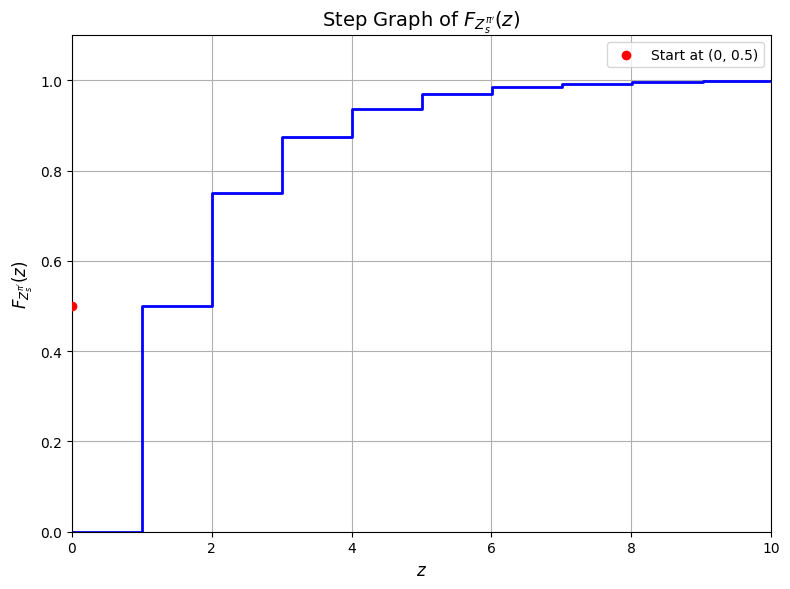

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define the function F_Zs_pi_prime
def F_Zs_pi_prime(z, p_pi=0.5, c_pi=1):
    return 1 - (1 - p_pi)**np.floor((z) / c_pi)

# Generate z values
z_values = np.linspace(0, 10, 500)

# Compute F(z)
F_values = F_Zs_pi_prime(z_values)

# Plotting
plt.figure(figsize=(8, 6))
plt.step(z_values, F_values, where='post', color='blue', linewidth=2)
plt.title(r"Step Graph of $F_{Z_{s}^{\pi'}}(z)$", fontsize=14)
plt.xlabel(r"$z$", fontsize=12)
plt.ylabel(r"$F_{Z_{s}^{\pi'}}(z)$", fontsize=12)
plt.grid(True)
plt.ylim(0, 1.1)
plt.xlim(0, 10)

# Highlighting the initial point
plt.scatter(0, 0.5, color='red', zorder=5, label='Start at (0, 0.5)')

# Show the legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [24]:
def F_Zs_pi_prime(z, p_pi=0.5, c_pi=1):
    return 1 - (1 - p_pi)**np.floor((z) / c_pi)

# Generate z values
z_values = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# Compute F(z)
F_values = F_Zs_pi_prime(z_values, p_pi=0.75, c_pi=2.5)
F_values

array([0.        , 0.        , 0.        , 0.75      , 0.75      ,
       0.9375    , 0.9375    , 0.9375    , 0.984375  , 0.984375  ,
       0.99609375])

# Gráficos Região de Configuração

In [25]:
c_pi = 1
z_values = np.arange(0, 9, 1)

df_cdf = pd.DataFrame()
df_cdf['Cost'] = np.floor((z_values+1) / c_pi)
df_cdf['Probability'] = F_values[:z_values[-1]+1]

In [26]:
add_probability = [v for v in df_cdf.Probability.unique() if v > 0.95]
add_probability

[0.984375]

In [27]:
arr_ra_eum, arr_ra_plt, arr_ra_var, arr_ra_cvar, arr_ra_vm = [], [], [], [], []
arr_rp_eum, arr_rp_plt, arr_rp_var, arr_rp_cvar, arr_rp_vm = [], [], [], [], []

range_p = np.arange(0.0, 1.0, 0.05)
range_p = np.append(range_p, add_probability)

for p_i in range_p:
    arr_ra_eum.append(analytical_extreme_risk_averse_eum(cr, pr, p_i))
    arr_rp_eum.append(analytical_extreme_risk_prone_eum(cr, pr, p_i))
    
    arr_ra_plt.append(analytical_extreme_risk_averse_plt(cr, pr, p_i))
    arr_rp_plt.append(analytical_extreme_risk_prone_plt(cr, pr, p_i))
    
    arr_ra_var.append(analytical_extreme_risk_averse_var(cr, pr, p_i))
    arr_rp_var.append(analytical_extreme_risk_prone_var(cr, pr, p_i))
    
    arr_ra_cvar.append(analytical_extreme_risk_averse_cvar(cr, pr, p_i))
    arr_rp_cvar.append(analytical_extreme_risk_prone_cvar(cr, pr, p_i))
    
    arr_ra_vm.append(analytical_extreme_risk_averse_vm(cr, pr, p_i))
    arr_rp_vm.append(analytical_extreme_risk_prone_vm(cr, pr, p_i))
    
arr_ra_eum, arr_ra_plt, arr_ra_var, arr_ra_cvar, arr_ra_vm = np.array(arr_ra_eum), np.array(arr_ra_plt), np.array(arr_ra_var), np.array(arr_ra_cvar), np.array(arr_ra_vm)
arr_rp_eum, arr_rp_plt, arr_rp_var, arr_rp_cvar, arr_rp_vm = np.array(arr_rp_eum), np.array(arr_rp_plt), np.array(arr_rp_var), np.array(arr_rp_cvar), np.array(arr_rp_vm)

In [28]:
# df_cdf = df_cdf[df_cdf.Probability <= add_probability]

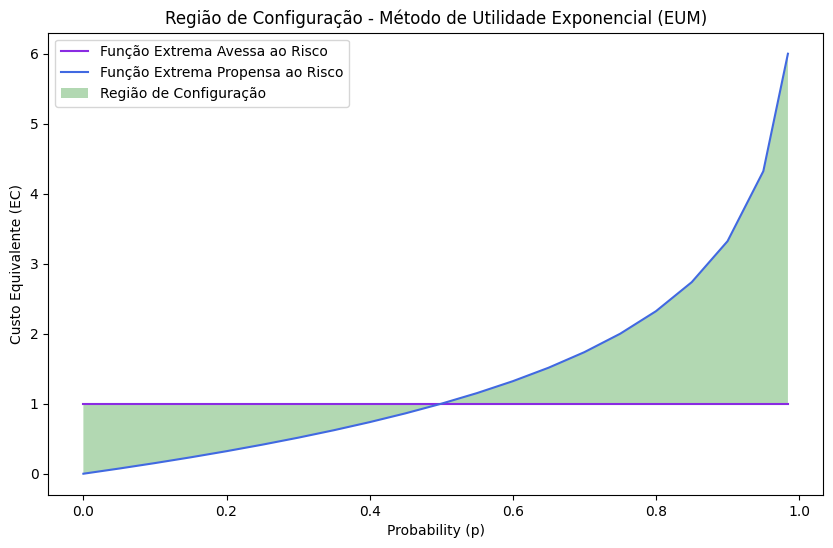

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Criação do gráfico
plt.figure(figsize=(10, 6))

# Plot das duas linhas
plt.plot(range_p, arr_ra_eum, color='blueviolet', label='Função Extrema Avessa ao Risco')
plt.plot(range_p, arr_rp_eum, color='royalblue', label='Função Extrema Propensa ao Risco')

# Preenchimento da área entre as duas linhas
plt.fill_between(range_p, arr_ra_eum, arr_rp_eum, where=((arr_rp_eum > arr_ra_eum) | (arr_rp_eum <= arr_ra_eum)), facecolor='green', alpha=0.3, interpolate=True, label='Região de Configuração')
# plt.fill_between(range_p, arr_ra_eum, max(arr_ra_eum.max(), arr_rp_eum.max()), where=((arr_rp_eum < arr_ra_eum) | (arr_rp_eum >= arr_ra_eum)), facecolor='yellow', alpha=0.3, interpolate=True, label='Área (cos > sen)')
# plt.fill_between(range_p, arr_ra_eum, min(arr_ra_eum.min(), arr_rp_eum.min()), where=((arr_rp_eum > arr_ra_eum) | (arr_rp_eum <= arr_ra_eum)), facecolor='red', alpha=0.3, interpolate=True, label='Área (cos > sen)')

# Adiciona rótulos e título
plt.xlabel('Probability (p)')
plt.ylabel('Custo Equivalente (EC)')
plt.title('Região de Configuração - Método de Utilidade Exponencial (EUM)')
plt.legend()

# Exibir o gráfico
plt.show()

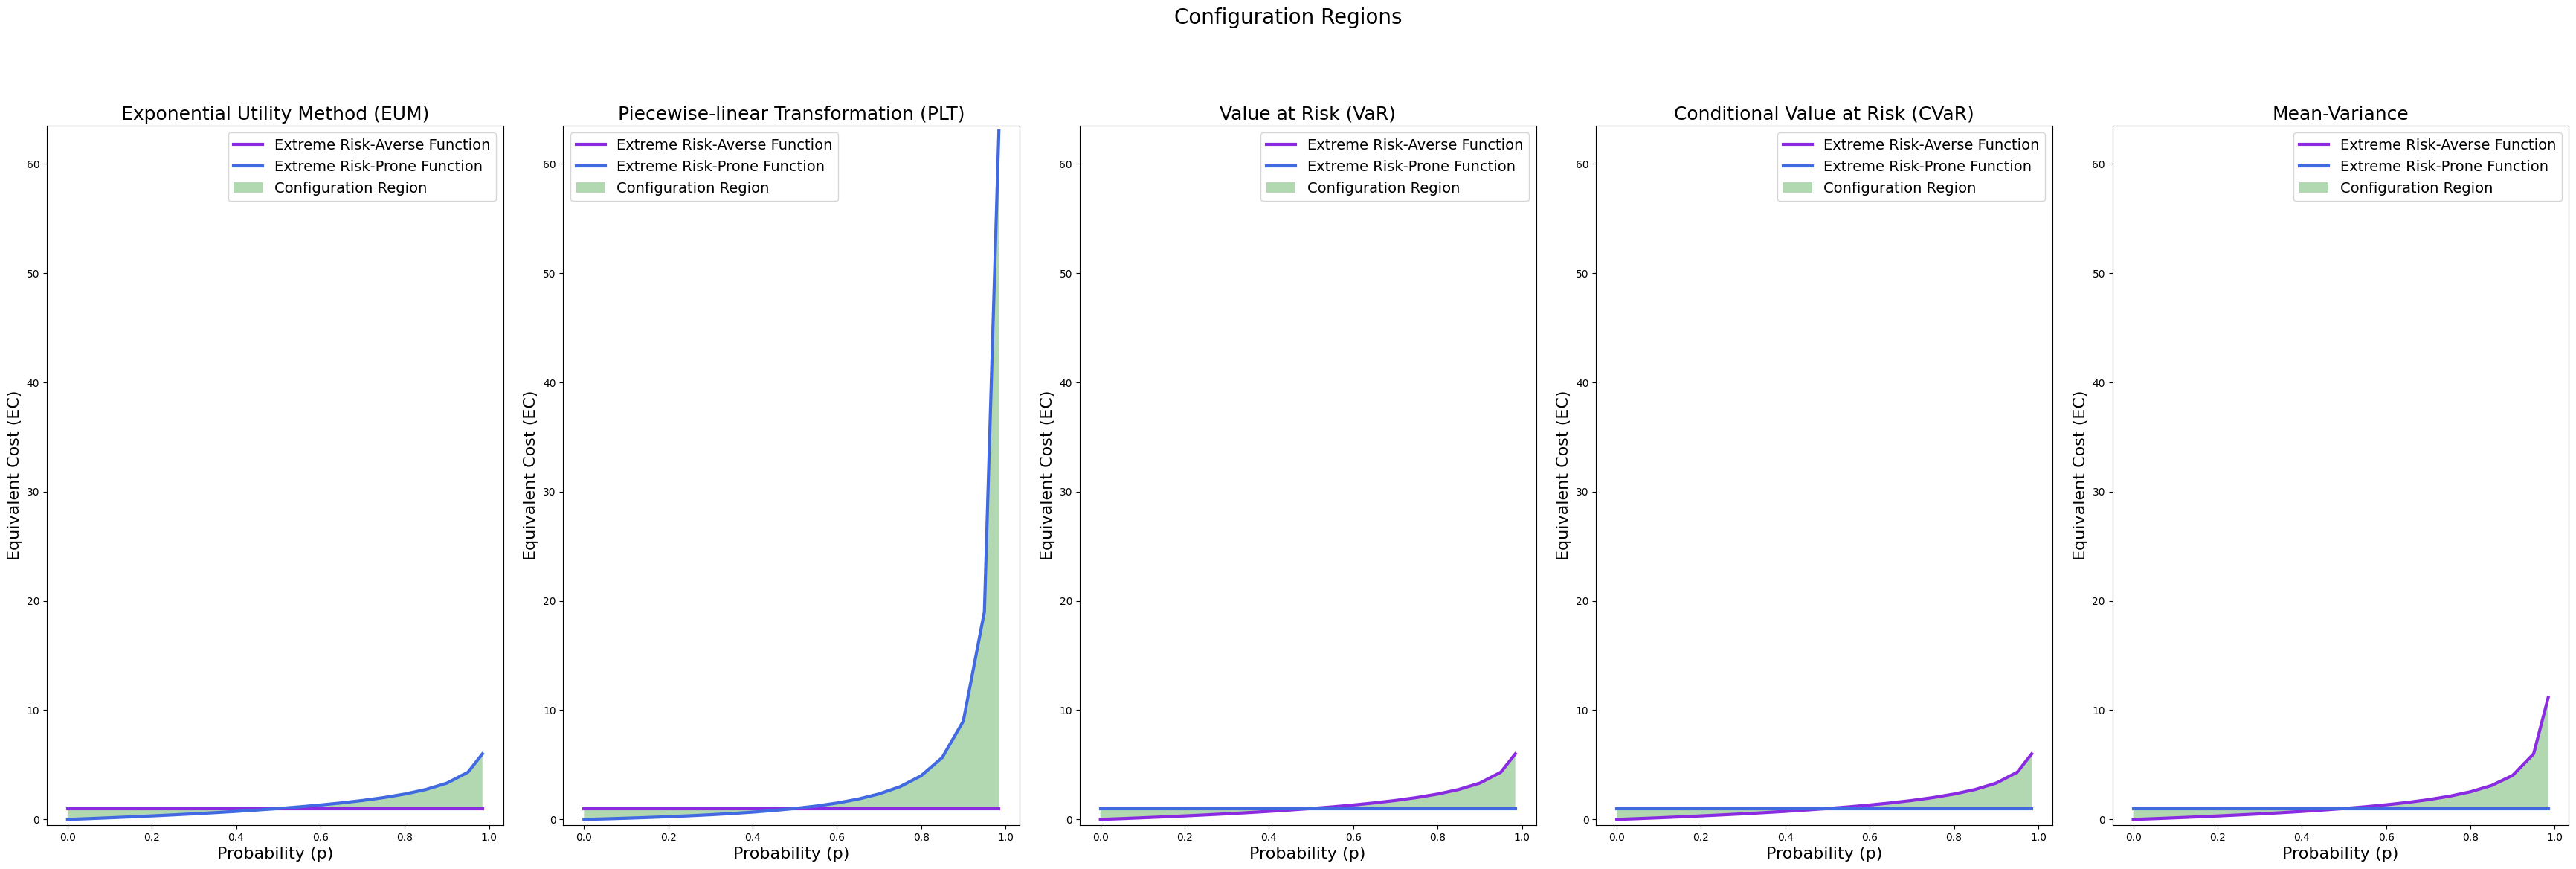

In [30]:
import matplotlib.pyplot as plt
import numpy as np

language = 'English'

# Define a large figure size for better readability in LaTeX documents
fig, axs = plt.subplots(1, 5, figsize=(35, 12))

# Flatten the subplots array for easier iteration
axes = axs.flatten()

# Find global y-axis limits
y_values = [arr_ra_eum, arr_rp_eum, arr_ra_plt, arr_rp_plt, arr_ra_var, arr_rp_var, arr_ra_cvar, arr_rp_cvar, arr_ra_vm, arr_rp_vm]
y_min = min([np.min(y) for y in y_values]) - 0.5
y_max = max([np.max(y) for y in y_values]) + 0.5

# Plotting function for each subplot with enhanced readability
def plot_graph(ax, y1, y2, psi):
    ax.plot(range_p, y1, color='blueviolet', linewidth=3, label='Extreme Risk-Averse Function' if language == 'English' else 'Função Extrema Avessa ao Risco')
    ax.plot(range_p, y2, color='royalblue', linewidth=3, label='Extreme Risk-Prone Function' if language == 'English' else 'Função Extrema Propensa ao Risco')
    
    ax.fill_between(range_p, y1, y2, where=((y2 > y1) | (y2 <= y1)), facecolor='green', alpha=0.3, interpolate=True, label='Configuration Region' if language == 'English' else 'Região de Configuração')
    ax.set_xlabel('Probability (p)' if language == 'English' else 'Probabilidade (p)', fontsize=16)
    ax.set_ylabel('Equivalent Cost (EC)' if language == 'English' else 'Custo Equivalente (EC)', fontsize=16)
    ax.legend(fontsize=14)
    ax.set_title(f'{psi}' if language == 'English' else f'{psi}', fontsize=18)
    ax.set_ylim(y_min, y_max)

# Plot each method on its corresponding subplot
plot_graph(axes[0], arr_ra_eum, arr_rp_eum, 'Exponential Utility Method (EUM)' if language == 'English' else 'Método de Utilidade Exponencial (EUM)')
plot_graph(axes[1], arr_ra_plt, arr_rp_plt, 'Piecewise-linear Transformation (PLT)' if language == 'English' else 'Transformação Linear por Partes (PLT)')
plot_graph(axes[2], arr_ra_var, arr_rp_var, 'Value at Risk (VaR)' if language == 'English' else 'Valor em Risco (VaR)')
plot_graph(axes[3], arr_ra_cvar, arr_rp_cvar, 'Conditional Value at Risk (CVaR)' if language == 'English' else 'Valor em Risco Condicional (CVaR)')
plot_graph(axes[4], arr_ra_vm, arr_rp_vm, 'Mean-Variance' if language == 'English' else 'Média-Variância')

# Add a global title for the figure
fig.suptitle('Configuration Regions' if language == 'English' else 'Regiões de Configuração', fontsize=20)

# Adjust layout to ensure the plots fit well
plt.tight_layout(rect=[0, 0, 1, 0.94], pad=2.0)

# Save the figure with high resolution
plt.savefig(f'static/{language}_regiao_configuracao_por_metodo.png', dpi=300)

# Display the plot
plt.show()


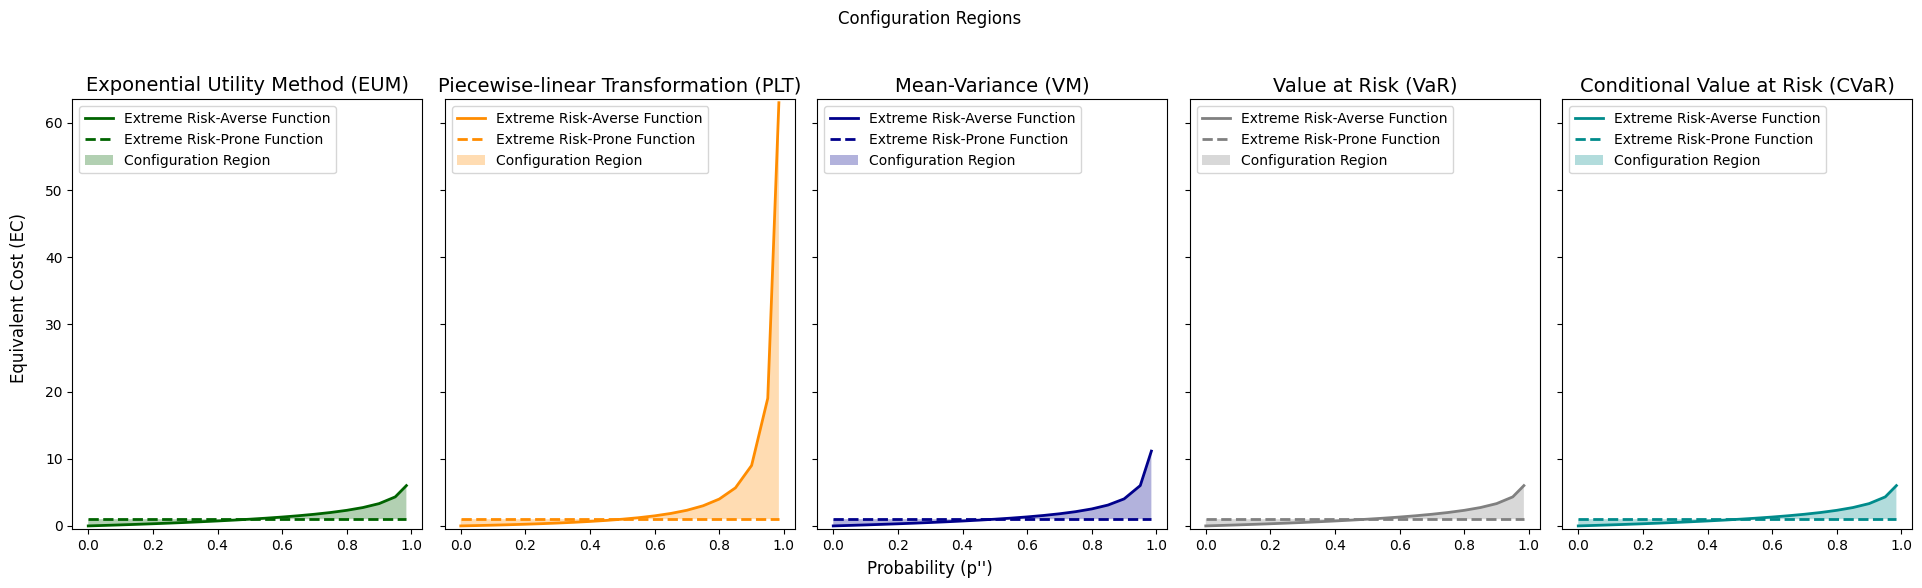

In [31]:
import matplotlib.pyplot as plt
import numpy as np

language = 'English'

# Create figure with 5 subplots
fig, axs = plt.subplots(1, 5, figsize=(20, 6), sharex=True, sharey=True)

# Flatten the axes for easier iteration
axes = axs.flatten()

# Find global y-axis limits
y_values = [arr_ra_eum, arr_rp_eum, arr_ra_plt, arr_rp_plt, arr_ra_var, arr_rp_var, arr_ra_cvar, arr_rp_cvar, arr_ra_vm, arr_rp_vm]
y_min = min([np.min(y) for y in y_values]) - 0.5
y_max = max([np.max(y) for y in y_values]) + 0.5

# Function to plot graphs with different colors for each region
def plot_graph(ax, y1, y2, psi, line_color):
    ax.plot(range_p, y1, color=line_color, label='Extreme Risk-Averse Function' if language == 'English' else 'Função Extrema Avessa ao Risco', linewidth=2)
    ax.plot(range_p, y2, color=line_color, linestyle='--', label='Extreme Risk-Prone Function' if language == 'English' else 'Função Extrema Propensa ao Risco', linewidth=2)
    
    ax.fill_between(range_p, y1, y2, where=((y2 > y1) | (y2 <= y1)), facecolor=line_color, alpha=0.3, interpolate=True, label='Configuration Region' if language == 'English' else 'Região de Configuração')
    ax.set_title(f'{psi}', fontsize=14)
    ax.set_ylim(y_min, y_max)  # Set y-axis limits
    ax.legend(fontsize=10, loc='upper left')

# Plot on each subplot with close colors for each region
plot_graph(axes[0], arr_rp_eum, arr_ra_eum, 'Exponential Utility Method (EUM)', 'darkgreen')
plot_graph(axes[1], arr_rp_plt, arr_ra_plt, 'Piecewise-linear Transformation (PLT)', 'darkorange')
plot_graph(axes[2], arr_ra_vm, arr_rp_vm, 'Mean-Variance (VM)', 'darkblue')
plot_graph(axes[3], arr_ra_var, arr_rp_var, 'Value at Risk (VaR)', 'gray')
plot_graph(axes[4], arr_ra_cvar, arr_rp_cvar, 'Conditional Value at Risk (CVaR)', 'darkcyan')

# Add a single x-axis and y-axis label
fig.text(0.5, 0.04, 'Probability (p\'\')' if language == 'English' else 'Probabilidade (p\'\')', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Equivalent Cost (EC)' if language == 'English' else 'Custo Equivalente (EC)', va='center', rotation='vertical', fontsize=12)

# Add a title to the figure
fig.suptitle('Configuration Regions' if language == 'English' else 'Regiões de Configuração')

# Adjust layout to avoid overlapping elements
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

# Save the plot
plt.savefig(r'static/{}_regiao_configuracao_por_metodo.png'.format(language), dpi=300)

# Show the plot
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


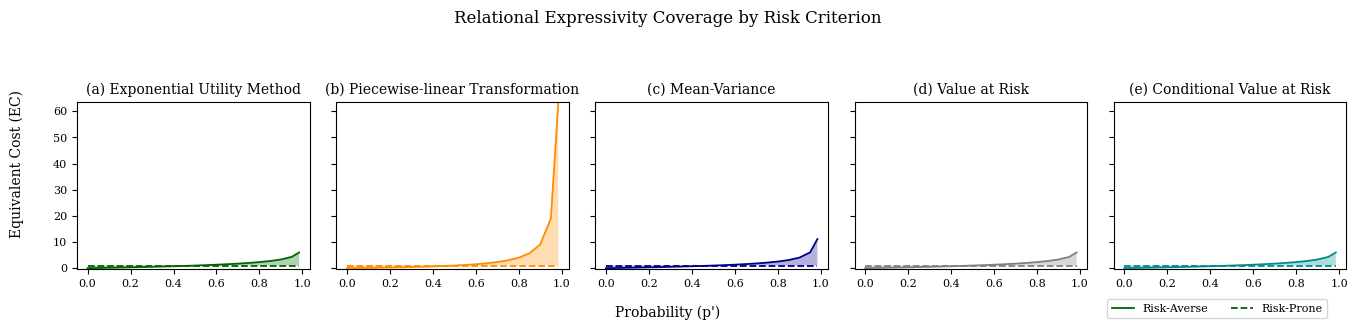

In [32]:
import matplotlib.pyplot as plt
import numpy as np

language = 'English'

# EPS-friendly styles
plt.rcParams.update({
    "figure.figsize": (14, 3.2),  # Wide layout for 1x5
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "lines.linewidth": 1.3,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "savefig.format": 'eps',
    "font.family": "serif",
    "pdf.use14corefonts": True,
    "ps.useafm": True,
})

# Method list
methods = [
    ('Exponential Utility Method', arr_rp_eum, arr_ra_eum, 'darkgreen'),
    ('Piecewise-linear Transformation', arr_rp_plt, arr_ra_plt, 'darkorange'),
    ('Mean-Variance', arr_ra_vm, arr_rp_vm, 'darkblue'),
    ('Value at Risk', arr_ra_var, arr_rp_var, 'gray'),
    ('Conditional Value at Risk', arr_ra_cvar, arr_rp_cvar, 'darkcyan'),
]

# Create 1-row, 5-column subplot
fig, axs = plt.subplots(1, 5, sharex=True, sharey=True)
axes = axs.flatten()

# Global y-axis range
all_y = [arr for _, a1, a2, _ in methods for arr in [a1, a2]]
y_min = min(np.min(arr) for arr in all_y) - 0.5
y_max = max(np.max(arr) for arr in all_y) + 0.5

# Subplot labels
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

# Plotting function
def plot_graph(ax, y1, y2, title, color, label_tag):
    ax.plot(range_p, y1, color=color, label='Risk-Averse')
    ax.plot(range_p, y2, color=color, linestyle='--', label='Risk-Prone')
    ax.fill_between(range_p, y1, y2, where=(y2 > y1) | (y2 <= y1),
                    facecolor=color, alpha=0.3, interpolate=True)
    ax.set_title(f"{label_tag} {title}", fontsize=10)
    ax.set_ylim(y_min, y_max)

# Plot each method
for i, (title, y1, y2, color) in enumerate(methods):
    plot_graph(axes[i], y1, y2, title, color, subplot_labels[i])

# Shared axis labels
fig.text(0.5, 0.02, "Probability (p')" if language == 'English' else "Probabilidade (p')", ha='center', fontsize=10)
fig.text(0.03, 0.5, "Equivalent Cost (EC)" if language == 'English' else "Custo Equivalente (EC)", va='center', rotation='vertical', fontsize=10)

# Global title
fig.suptitle("Relational Expressivity Coverage by Risk Criterion", fontsize=12)

# Common legend below
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', ncol=2, bbox_to_anchor=(0.975, 0))

# Final layout adjustment
plt.tight_layout(rect=[0.05, 0.06, 1, 0.90])

# Save as EPS
plt.savefig(f'static/{language}_relational_expressivity_coverage.eps', format='eps', bbox_inches='tight')
plt.show()


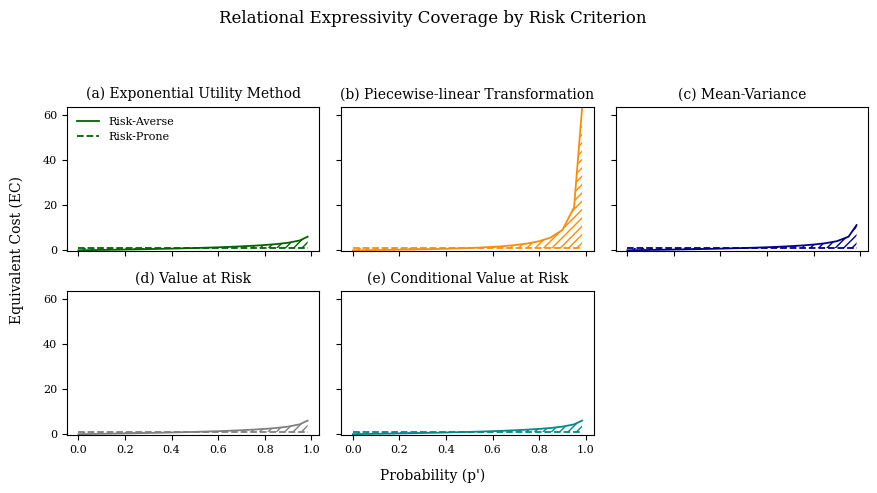

In [33]:
import matplotlib.pyplot as plt
import numpy as np

language = 'English'

# EPS-safe style
plt.rcParams.update({
    "figure.figsize": (9, 5),  # Adapted for 2 rows
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "lines.linewidth": 1.3,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "savefig.format": 'eps',
    "font.family": "serif",
    "pdf.use14corefonts": True,
    "ps.useafm": True,
})

# Method list
methods = [
    ('Exponential Utility Method', arr_rp_eum, arr_ra_eum, 'darkgreen'),
    ('Piecewise-linear Transformation', arr_rp_plt, arr_ra_plt, 'darkorange'),
    ('Mean-Variance', arr_ra_vm, arr_rp_vm, 'darkblue'),
    ('Value at Risk', arr_ra_var, arr_rp_var, 'gray'),
    ('Conditional Value at Risk', arr_ra_cvar, arr_rp_cvar, 'darkcyan'),
]

# Create 2x3 subplot layout (leave last subplot empty)
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True)
axes = axs.flatten()

# Global y-axis limits
all_y = [arr for _, a1, a2, _ in methods for arr in [a1, a2]]
y_min = min(np.min(arr) for arr in all_y) - 0.5
y_max = max(np.max(arr) for arr in all_y) + 0.5

# Subplot labels
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

# EPS-safe fill function with hatch
def plot_graph(ax, y1, y2, title, color, label_tag):
    ax.plot(range_p, y1, color=color, label='Risk-Averse')
    ax.plot(range_p, y2, color=color, linestyle='--', label='Risk-Prone')
    ax.fill_between(
        range_p, y1, y2,
        where=(y2 > y1) | (y2 <= y1),
        facecolor='white',
        edgecolor=color,
        hatch='////',
        linewidth=0.0,
        interpolate=True,
        zorder=0
    )
    ax.set_title(f"{label_tag} {title}", fontsize=10)
    ax.set_ylim(y_min, y_max)

# Plot each method
for i, (title, y1, y2, color) in enumerate(methods):
    plot_graph(axes[i], y1, y2, title, color, subplot_labels[i])

# Remove the unused 6th subplot
fig.delaxes(axes[-1])

# Axis labels
fig.text(0.5, 0.04, "Probability (p')" if language == 'English' else "Probabilidade (p')", ha='center', fontsize=10)
fig.text(0.03, 0.5, "Equivalent Cost (EC)" if language == 'English' else "Custo Equivalente (EC)", va='center', rotation='vertical', fontsize=10)

# Title
fig.suptitle("Relational Expressivity Coverage by Risk Criterion", fontsize=12)

# Legend inside first subplot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc='upper left', frameon=False)

# Adjust layout
plt.tight_layout(rect=[0.05, 0.06, 1, 0.92])

# Save as EPS
plt.savefig(f'static/{language}_relational_expressivity_coverage.eps', format='eps', bbox_inches='tight')
plt.show()


In [34]:
# params = [
#     {'c': 1, 'p': 0.5, 'label': r'$\pi\': c\' = 1, p\' = 0.5$'}
# ]

# for param in params:
#     cdf_prob_values_ceil = cdf(x_values, param['p'], param['c'], ceil=True)
#     cdf_prob_values = cdf(x_values, param['p'], param['c'], ceil=False)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


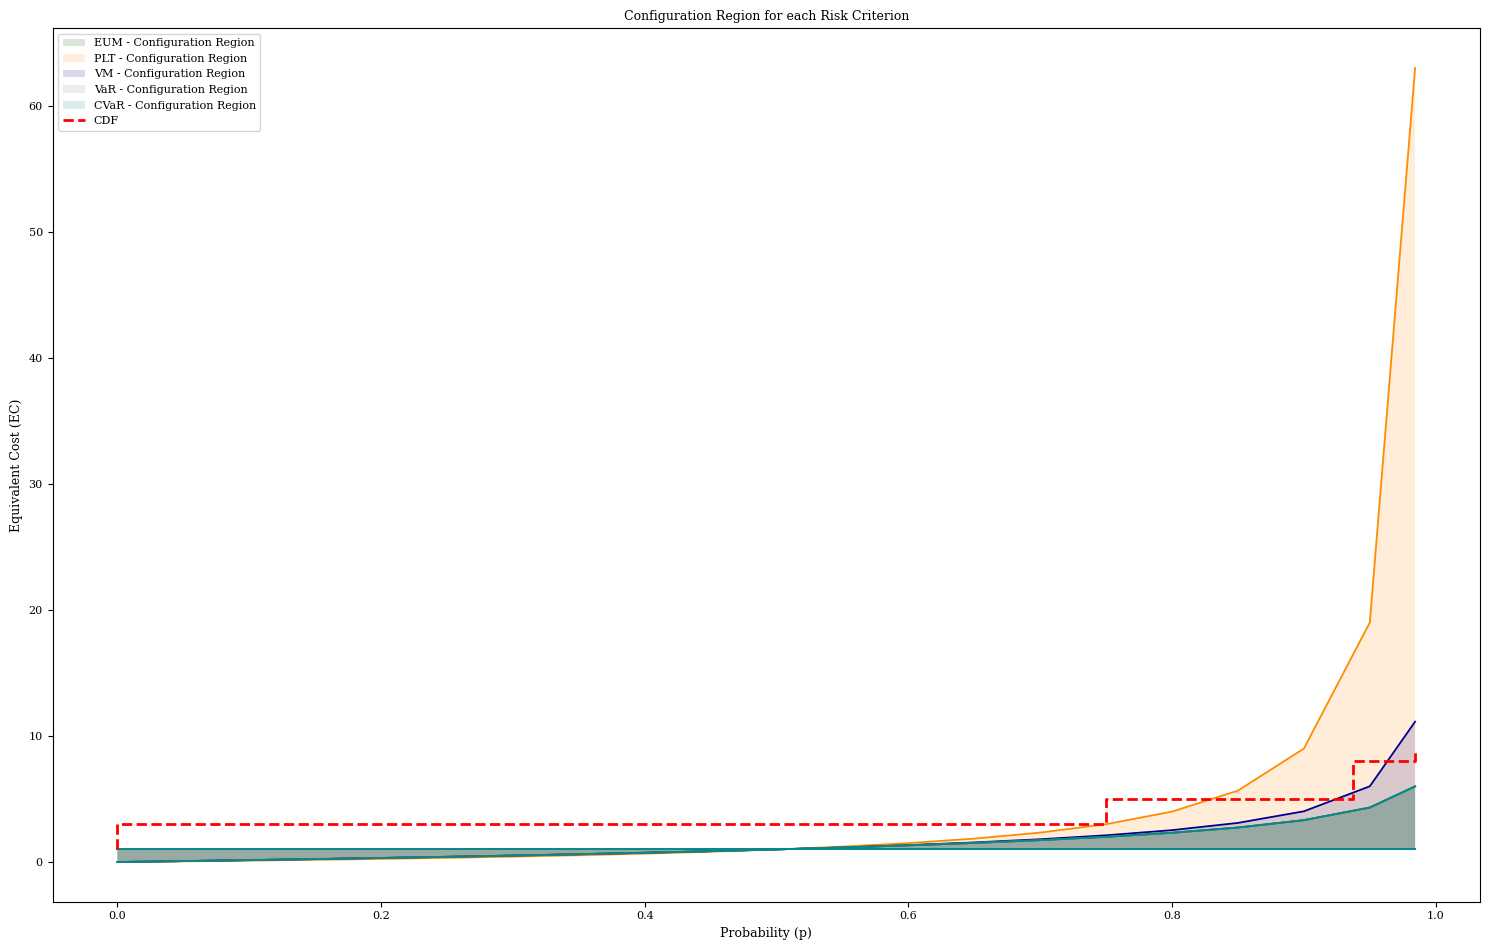

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Criação da figura
plt.figure(figsize=(15, 10))

# Plot das duas linhas e preenchimento das áreas
def plot_combined_graph(y1, y2, psi, color1, color2, fill_color, alpha, range_p):
    plt.plot(range_p, y1, color=color1)#, label=f'{psi} - Função Extrema Avessa ao Risco')
    plt.plot(range_p, y2, color=color2)#, label=f'{psi} - Função Extrema Propensa ao Risco')
    plt.fill_between(range_p, y1, y2, where=(y2 > y1) | (y2 <= y1), facecolor=fill_color, alpha=alpha, interpolate=True, label=f'{psi} - Região de Configuração' if language == 'Portuguese' else f'{psi} - Configuration Region')

# Adiciona os gráficos combinados
plot_combined_graph(arr_ra_eum, arr_rp_eum, 'EUM', 'darkgreen', 'darkgreen', 'darkgreen', 0.15, range_p)
plot_combined_graph(arr_ra_plt, arr_rp_plt, 'PLT', 'darkorange', 'darkorange', 'darkorange', 0.15, range_p)
plot_combined_graph(arr_ra_vm, arr_rp_vm, 'VM', 'darkblue', 'darkblue', 'darkblue', 0.15, range_p)
plot_combined_graph(arr_ra_var, arr_rp_var, 'VaR', 'gray', 'gray', 'gray', 0.15, range_p)
plot_combined_graph(arr_ra_cvar, arr_rp_cvar, 'CVaR', 'darkcyan', 'darkcyan', 'darkcyan', 0.15, range_p)

# plot_combined_graph(df_cdf.Cost, df_cdf.Cost, 'CDF', 'red', 'red', 'red', 0.3, df_cdf['Probability'])
plt.step(df_cdf.Probability, df_cdf.Cost, where='post', color='red', linewidth=2, label='CDF', linestyle='--')

# Adiciona rótulos e título
plt.xlabel('Probabilidade (p)' if language == 'Portuguese' else 'Probability (p)')
plt.ylabel('Custo Equivalente (EC)' if language == 'Portuguese' else 'Equivalent Cost (EC)')
plt.title('Regiões de Configuração Combinadas' if language == 'Portuguese' else 'Configuration Region for each Risk Criterion')

# Adiciona a legenda
plt.legend()

# Ajustar o layout para não sobrepor os elementos
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Salvar a imagem em PNG
# plt.savefig(os.path.join('static', f'{language}_regiao_configuracao_combinada.png'))
plt.savefig(os.path.join('static', f'{language}_regiao_configuracao_combinada.eps'), format='eps')

# Exibir o gráfico
plt.show()


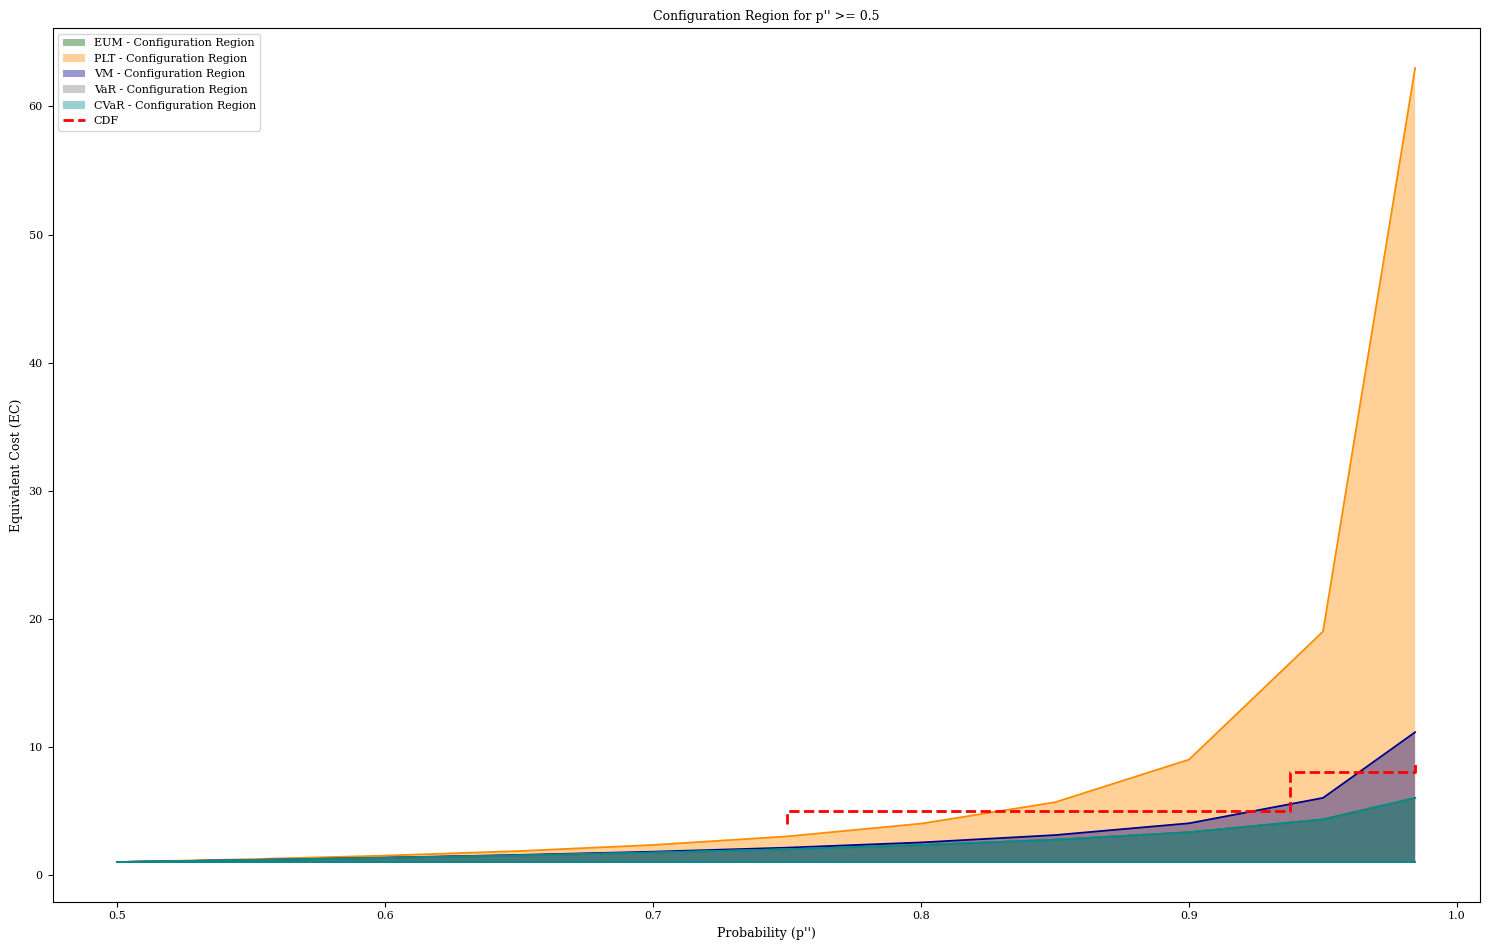

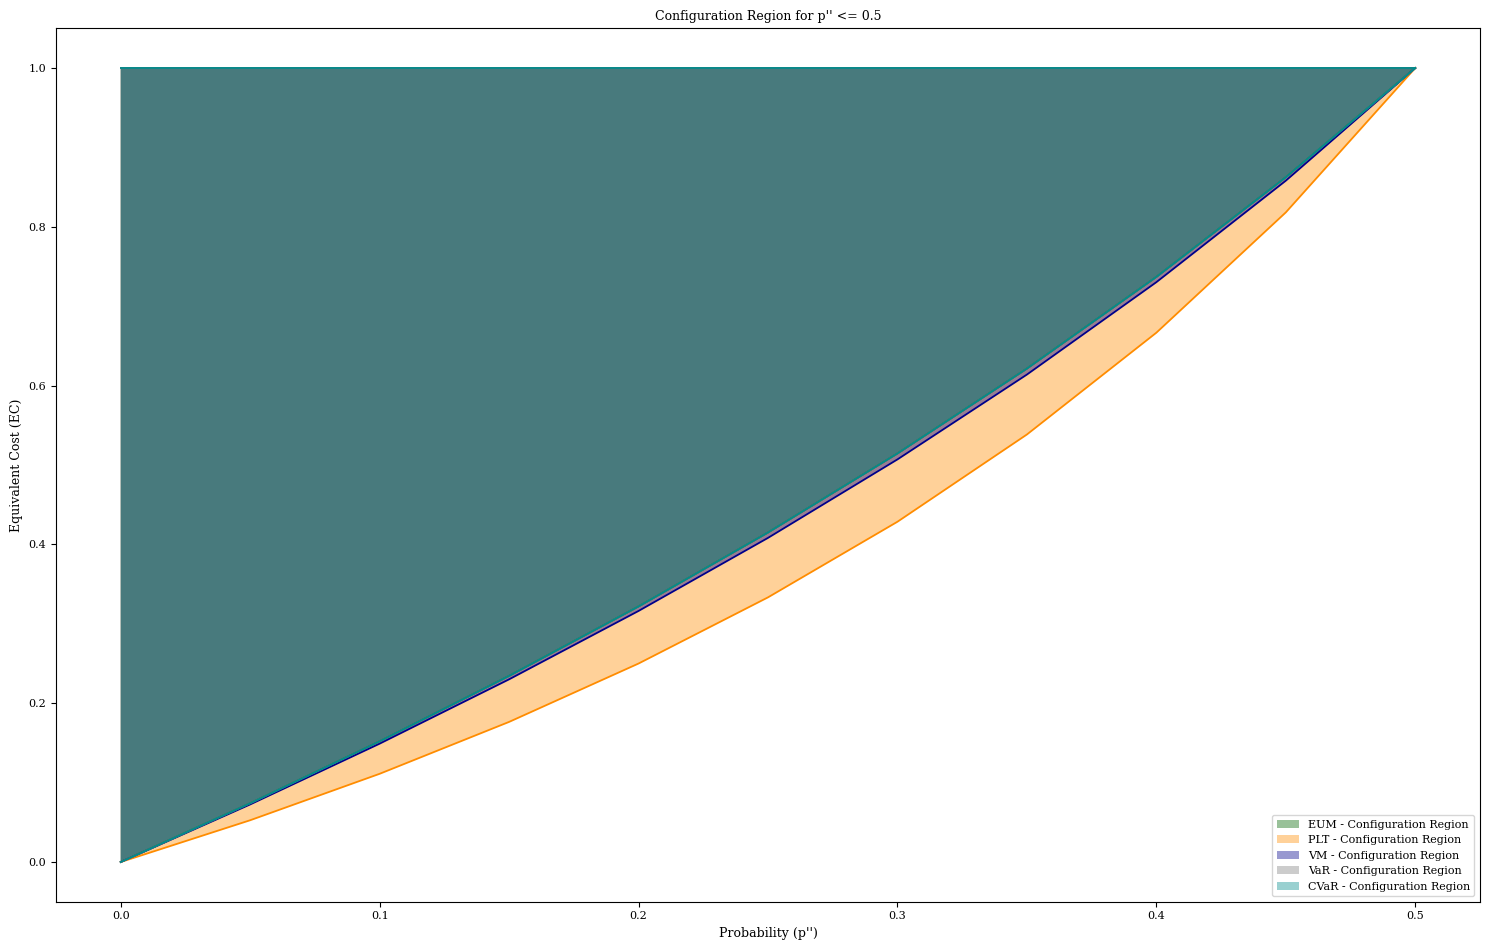

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar os dados para os dois gráficos
mask1 = range_p >= 0.5
mask2 = range_p <= 0.5

range_p1 = range_p[mask1]
range_p2 = range_p[mask2]

# Criação da função para plotar os gráficos combinados
def plot_combined_graph(range_p, y1, y2, psi, color1, color2, fill_color, alpha):
    plt.plot(range_p, y1, color=color1)#, label=f'{psi} - Função Extrema Avessa ao Risco')
    plt.plot(range_p, y2, color=color2)#, label=f'{psi} - Função Extrema Propensa ao Risco')
    plt.fill_between(range_p, y1, y2, where=(y2 > y1) | (y2 <= y1), facecolor=fill_color, alpha=alpha, interpolate=True, label=f'{psi} - Região de Configuração' if language == 'Portuguese' else f'{psi} - Configuration Region')

# Plotar o primeiro gráfico para range_p >= 0.5
plt.figure(figsize=(15, 10))
plot_combined_graph(range_p1, arr_ra_eum[mask1], arr_rp_eum[mask1], 'EUM', 'darkgreen', 'darkgreen', 'darkgreen', 0.4)
plot_combined_graph(range_p1, arr_ra_plt[mask1], arr_rp_plt[mask1], 'PLT', 'darkorange', 'darkorange', 'darkorange', 0.4)
plot_combined_graph(range_p1, arr_ra_vm[mask1], arr_rp_vm[mask1], 'VM', 'darkblue', 'darkblue', 'darkblue', 0.4)
plot_combined_graph(range_p1, arr_ra_var[mask1], arr_rp_var[mask1], 'VaR', 'gray', 'gray', 'gray', 0.4)
plot_combined_graph(range_p1, arr_ra_cvar[mask1], arr_rp_cvar[mask1], 'CVaR', 'darkcyan', 'darkcyan', 'darkcyan', 0.4)
plt.step(df_cdf[df_cdf['Probability'] >= 0.5].Probability, df_cdf[df_cdf['Probability'] >= 0.5].Cost, where='post', color='red', linewidth=2, label='CDF', linestyle='--')

plt.xlabel('Probabilidade (p\'\')' if language == 'Portuguese' else 'Probability (p\'\')')
plt.ylabel('Custo Equivalente (EC)' if language == 'Portuguese' else 'Equivalent Cost (EC)')
plt.title('Regiões de Configuração para p >= 0.5' if language == 'Portuguese' else 'Configuration Region for p\'\' >= 0.5')
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'static/{language}_regiao_configuracao_maior_igual_0.5.png')
plt.show()

# Plotar o segundo gráfico para range_p <= 0.5
plt.figure(figsize=(15, 10))
plot_combined_graph(range_p2, arr_ra_eum[mask2], arr_rp_eum[mask2], 'EUM', 'darkgreen', 'darkgreen', 'darkgreen', 0.4)
plot_combined_graph(range_p2, arr_ra_plt[mask2], arr_rp_plt[mask2], 'PLT', 'darkorange', 'darkorange', 'darkorange', 0.4)
plot_combined_graph(range_p2, arr_ra_vm[mask2], arr_rp_vm[mask2], 'VM', 'darkblue', 'darkblue', 'darkblue', 0.4)
plot_combined_graph(range_p2, arr_ra_var[mask2], arr_rp_var[mask2], 'VaR', 'gray', 'gray', 'gray', 0.4)
plot_combined_graph(range_p2, arr_ra_cvar[mask2], arr_rp_cvar[mask2], 'CVaR', 'darkcyan', 'darkcyan', 'darkcyan', 0.4)
plt.xlabel('Probabilidade (p)' if language == 'Portuguese' else 'Probability (p\'\')')
plt.ylabel('Custo Equivalente (EC)' if language == 'Portuguese' else 'Equivalent Cost (EC)')
plt.title('Regiões de Configuração para p <= 0.5' if language == 'Portuguese' else 'Configuration Region for p\'\' <= 0.5')
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'static/{language}_regiao_configuracao_menor_igual_0.5.png')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


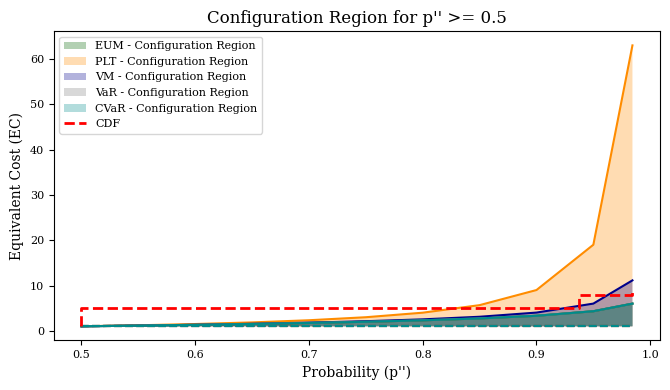

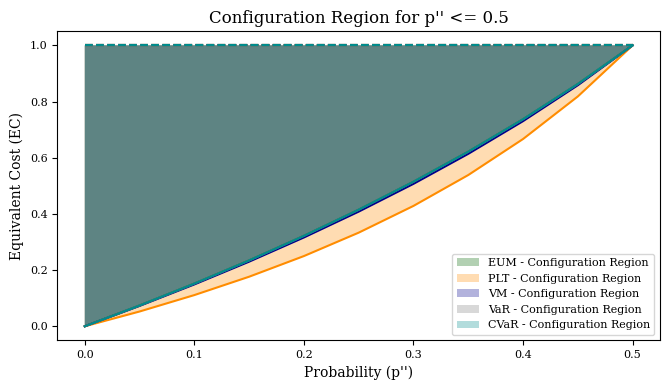

In [37]:
import matplotlib.pyplot as plt
import numpy as np

language = 'English'

# Define consistent colors and line styles
colors = {
    'EUM': 'darkgreen',
    'PLT': 'darkorange',
    'VM': 'darkblue',
    'VaR': 'gray',
    'CVaR': 'darkcyan'
}
line_styles = {
    'EUM': '-',
    'PLT': '-',
    'VM': '-',
    'VaR': '-',
    'CVaR': '-'
}

# Function to plot combined graphs
def plot_combined_graph(range_p, y1, y2, psi, method):
    color = colors[method]
    linestyle = line_styles[method]
    
    plt.plot(range_p, y1, color=color, linestyle=linestyle, linewidth=1.5)#, label=f'{psi} - Risk-Averse Function')
    plt.plot(range_p, y2, color=color, linestyle='--', linewidth=1.5)#, label=f'{psi} - Risk-Prone Function')
    plt.fill_between(range_p, y1, y2, where=(y2 > y1) | (y2 <= y1),
                     facecolor=color, alpha=0.3, interpolate=True, label=f'{psi} - Configuration Region')

# Set common plot parameters for better visibility
plt.rcParams.update({
    "figure.figsize": (8, 4),  # Adjust size to fit textwidth
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "lines.linewidth": 1.5,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

# Plot for range_p >= 0.5
plt.figure()
plot_combined_graph(range_p1, arr_rp_eum[mask1], arr_ra_eum[mask1], 'EUM', 'EUM')
plot_combined_graph(range_p1, arr_rp_plt[mask1], arr_ra_plt[mask1], 'PLT', 'PLT')
plot_combined_graph(range_p1, arr_ra_vm[mask1], arr_rp_vm[mask1], 'VM', 'VM')
plot_combined_graph(range_p1, arr_ra_var[mask1], arr_rp_var[mask1], 'VaR', 'VaR')
plot_combined_graph(range_p1, arr_ra_cvar[mask1], arr_rp_cvar[mask1], 'CVaR', 'CVaR')

df_cdf_up = df_cdf.copy()
df_cdf_up.loc[df_cdf_up.Probability <= 0.75, 'Probability'] = 0.5

plt.step(df_cdf_up[df_cdf_up['Probability'] >= 0.5].Probability, df_cdf_up[df_cdf_up['Probability'] >= 0.5].Cost, where='post', color='red', linewidth=2, label='CDF', linestyle='--')

plt.xlabel('Probability (p\'\')' if language == 'Portuguese' else 'Probability (p\'\')')
plt.ylabel('Equivalent Cost (EC)' if language == 'Portuguese' else 'Equivalent Cost (EC)')
plt.title('Configuration Regions for p >= 0.5' if language == 'Portuguese' else 'Configuration Region for p\'\' >= 0.5')

# Place legend inside the graph area
plt.legend(loc='best', fontsize=8)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to fit content
# plt.savefig(f'static/{language}_regiao_configuracao_maior_igual_0.5.png', dpi=300)
plt.savefig(f'static/{language}_regiao_configuracao_maior_igual_0.5.eps', format='eps')
plt.show()

# Plot for range_p <= 0.5
plt.figure()
plot_combined_graph(range_p2, arr_rp_eum[mask2], arr_ra_eum[mask2], 'EUM', 'EUM')
plot_combined_graph(range_p2, arr_rp_plt[mask2], arr_ra_plt[mask2], 'PLT', 'PLT')
plot_combined_graph(range_p2, arr_ra_vm[mask2], arr_rp_vm[mask2], 'VM', 'VM')
plot_combined_graph(range_p2, arr_ra_var[mask2], arr_rp_var[mask2], 'VaR', 'VaR')
plot_combined_graph(range_p2, arr_ra_cvar[mask2], arr_rp_cvar[mask2], 'CVaR', 'CVaR')

plt.xlabel('Probability (p)' if language == 'Portuguese' else 'Probability (p\'\')')
plt.ylabel('Equivalent Cost (EC)' if language == 'Portuguese' else 'Equivalent Cost (EC)')
plt.title('Configuration Regions for p <= 0.5' if language == 'Portuguese' else 'Configuration Region for p\'\' <= 0.5')

# Place legend inside the graph area
plt.legend(loc='best', fontsize=8)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to fit content
plt.savefig(f'static/{language}_regiao_configuracao_menor_igual_0.5.png', dpi=300)
plt.show()


<>:92: SyntaxWarning: invalid escape sequence '\g'
<>:92: SyntaxWarning: invalid escape sequence '\g'
C:\Users\igorm\AppData\Local\Temp\ipykernel_8440\3800239300.py:92: SyntaxWarning: invalid escape sequence '\g'
  "Relational Expressivity Coverage for $p' \geq 0.5$" if language == 'English' else "Cobertura de Expressividade Relacional para p' ≥ 0.5"
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


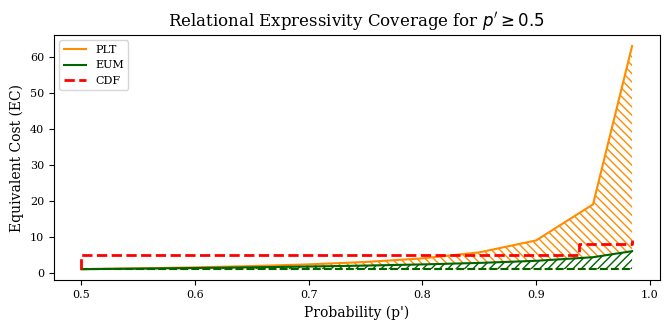

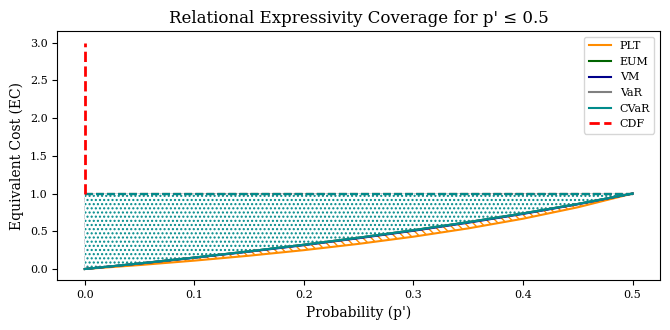

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Language toggle for labels
language = 'English'

# === Style settings for publication ===
plt.rcParams.update({
    "figure.figsize": (6.8, 3.4),  # Suitable for textwidth (~2-column layout)
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "lines.linewidth": 1.5,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "savefig.dpi": 300,
    "savefig.format": 'eps',
    "pdf.use14corefonts": True,
    "ps.useafm": True,
    "font.family": "serif"
})

# === Colors and styles for each method ===
colors = {
    'EUM': 'darkgreen',
    'PLT': 'darkorange',
    'VM': 'darkblue',
    'VaR': 'gray',
    'CVaR': 'darkcyan'
}
line_styles = {
    'default': '-',
    'contrast': '--'
}
hatches = {
    'EUM': '////',
    'PLT': '\\\\\\\\',
    'VM': 'xxxx',
    'VaR': '----',
    'CVaR': '....'
}

# === Plotting function for each method ===
def plot_method(ax, x, y1, y2, method, label_prefix=''):
    color = colors[method]
    hatch = hatches[method]
    ax.plot(x, y1, color=color, linestyle=line_styles['default'], label=f'{label_prefix}{method}')
    ax.plot(x, y2, color=color, linestyle=line_styles['contrast'])
    ax.fill_between(
        x, y1, y2,
        where=(y2 > y1) | (y2 <= y1),
        facecolor='white',
        edgecolor=color,
        hatch=hatch,
        linewidth=0.0,
        interpolate=True
    )

# === General plotting function ===
def plot_configuration_region(ax, x, methods_data, cdf_x, cdf_y, title):
    for method, (y1, y2) in methods_data.items():
        plot_method(ax, x, y1, y2, method)
    
    # Plot CDF line
    ax.step(cdf_x, cdf_y, where='post', color='red', linestyle='--', linewidth=2, label='CDF')

    # Axis labeling
    ax.set_xlabel("Probability (p')" if language == 'English' else 'Probabilidade (p\')')
    ax.set_ylabel("Equivalent Cost (EC)" if language == 'English' else 'Custo Equivalente (CE)')
    ax.set_title(title)
    ax.legend(loc='best')

# === Example: Adjust your data inputs accordingly ===
df_cdf_up = df_cdf.copy()
df_cdf_up.loc[df_cdf_up.Probability <= 0.75, 'Probability'] = 0.5

# ===================
# First plot: p' ≥ 0.5
# ===================
fig1, ax1 = plt.subplots()
methods_data_1 = {
    'PLT': (arr_rp_plt[mask1], arr_ra_plt[mask1]),
    'EUM': (arr_rp_eum[mask1], arr_ra_eum[mask1]),
    # Add others here if needed
}
plot_configuration_region(
    ax1,
    range_p1,
    methods_data_1,
    df_cdf_up[df_cdf_up.Probability >= 0.5].Probability,
    df_cdf_up[df_cdf_up.Probability >= 0.5].Cost,
    "Relational Expressivity Coverage for $p' \geq 0.5$" if language == 'English' else "Cobertura de Expressividade Relacional para p' ≥ 0.5"
)
fig1.tight_layout()
fig1.savefig(f'static/{language}_regiao_configuracao_maior_igual_0.5.eps')

# ===================
# Second plot: p' ≤ 0.5
# ===================
fig2, ax2 = plt.subplots()
methods_data_2 = {
    'PLT': (arr_rp_plt[mask2], arr_ra_plt[mask2]),
    'EUM': (arr_rp_eum[mask2], arr_ra_eum[mask2]),
    'VM': (arr_ra_vm[mask2], arr_rp_vm[mask2]),
    'VaR': (arr_ra_var[mask2], arr_rp_var[mask2]),
    'CVaR': (arr_ra_cvar[mask2], arr_rp_cvar[mask2])
}
plot_configuration_region(
    ax2,
    range_p2,
    methods_data_2,
    df_cdf[df_cdf.Probability <= 0.5].Probability,
    df_cdf[df_cdf.Probability <= 0.5].Cost,
    "Relational Expressivity Coverage for p' ≤ 0.5" if language == 'English' else "Cobertura de Expressividade Relacional para p' ≤ 0.5"
)
fig2.tight_layout()
fig2.savefig(f'static/{language}_regiao_configuracao_menor_igual_0.5.eps')

plt.show()

In [39]:
range_p1

array([0.5     , 0.55    , 0.6     , 0.65    , 0.7     , 0.75    ,
       0.8     , 0.85    , 0.9     , 0.95    , 0.984375])

In [40]:
df_cdf_up

,Cost,Probability
0,1.0,0.500000
1,2.0,0.500000
2,3.0,0.500000
3,4.0,0.500000
4,5.0,0.500000
5,6.0,0.937500
6,7.0,0.937500
7,8.0,0.937500
8,9.0,0.984375


In [41]:
df_cdf_up

,Cost,Probability
0,1.0,0.500000
1,2.0,0.500000
2,3.0,0.500000
3,4.0,0.500000
4,5.0,0.500000
5,6.0,0.937500
6,7.0,0.937500
7,8.0,0.937500
8,9.0,0.984375


In [42]:
def F_Zs_pi_prime(z, p_pi=0.5, c_pi=1):
    return 1 - (1 - p_pi)**np.floor((z+1) / c_pi)

# Generate z values
z_values = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# Compute F(z)
F_values = F_Zs_pi_prime(z_values, p_pi=0.75, c_pi=2.5)
F_values

array([0.        , 0.        , 0.75      , 0.75      , 0.9375    ,
       0.9375    , 0.9375    , 0.984375  , 0.984375  , 0.99609375,
       0.99609375])

In [43]:
p = 0.5
c = 1

In [44]:
print(f'Custo igual a 4*{c}: {p - (1-p)*p - (1-p)**2*p - (1-p)**3*p}')
print(f'Custo igual a 3*{c}: {p - (1-p)*p - (1-p)**2*p}')
print(f'Custo igual a 2*{c}: {p - (1-p)*p}')
print(f'Custo igual a {c}: {p}')
print(f'Custo igual a 2*{c}: {p + (1-p)*p}')
print(f'Custo igual a 3*{c}: {p + (1-p)*p + (1-p)**2*p}')
print(f'Custo igual a 4*{c}: {p + (1-p)*p + (1-p)**2*p + (1-p)**3*p}')

Custo igual a 4*1: 0.0625
Custo igual a 3*1: 0.125
Custo igual a 2*1: 0.25
Custo igual a 1: 0.5
Custo igual a 2*1: 0.75
Custo igual a 3*1: 0.875
Custo igual a 4*1: 0.9375


In [45]:
c_pi = 1

df_cdf = pd.DataFrame()
df_cdf['Cost'] = np.floor((z_values+1) / c_pi)
df_cdf['Probability'] = F_values

In [46]:
df_cdf

,Cost,Probability
0,1.0,0.000000
1,2.0,0.000000
2,3.0,0.750000
3,4.0,0.750000
4,5.0,0.937500
5,6.0,0.937500
6,7.0,0.937500
7,8.0,0.984375
8,9.0,0.984375
9,10.0,0.996094


# Exemplo REC (Relational Expressivity Coverage)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


'static/equivalent_cost_full_area_colored.eps'

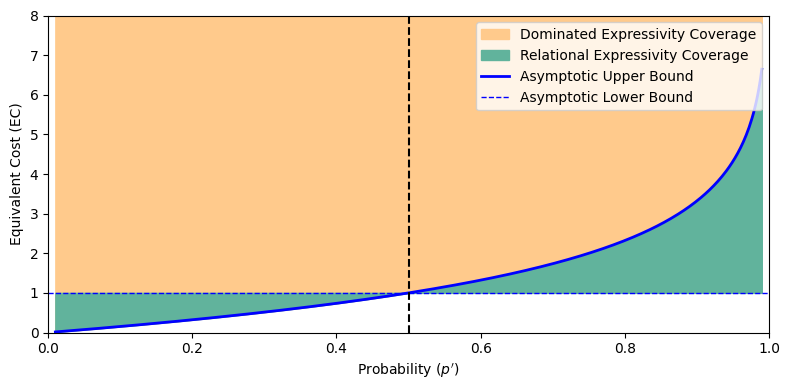

In [21]:
# Redefine: compute function and properly color all areas as described
pr = np.linspace(0.01, 0.99, 500)
cr = 1.0
p = 0.5  # fixed

# Define the function
def f_psi(pr, p, cr):
    return cr * np.log(1 - pr) / np.log(1 - p)

ec = f_psi(pr, p, cr)

# Create plot
fig, ax = plt.subplots(figsize=(8, 4))

# Fill above the curve
ax.fill_between(pr, 8, ec, color='#FFCA8C', label='Dominated Expressivity Coverage')  # Green

# Fill below the curve (from y=0 to ec)
# ax.fill_between(pr, 0, ec, color='#FF8E92', label='')  # Green

# Fill between the curve and cr (if ec < cr)
ax.fill_between(pr, ec, cr, where=ec < cr, color='#61B39C', label='Relational Expressivity Coverage')  # Orange

# Fill above cr (if ec > cr)
ax.fill_between(pr, cr, ec, where=ec > cr, color='#61B39C', label='')  # Red

# Plot curve and reference lines
ax.plot(pr, ec, color='blue', linewidth=2, label='Asymptotic Upper Bound')
ax.axhline(y=cr, color='blue', linestyle='--', linewidth=1, label='Asymptotic Lower Bound')
ax.axvline(x=p, color='black', linestyle='--')

# Annotations
ax.set_xlabel("Probability ($p'$)")
ax.set_ylabel("Equivalent Cost (EC)")

# Axis settings
ax.set_xlim(0, 1)
ax.set_ylim(0, 8)
ax.legend(loc='upper right')
plt.tight_layout()
plt.title('Visual Representation of the Relational Expressivity Coverage (REC) method')

# Save as EPS
final_area_path = "static/equivalent_cost_full_area_colored.eps"
plt.savefig(final_area_path, format='eps')
final_area_path
